# **UAS PHONEME**

# **BUSINESS UNDERSTANDING**

---



Dalam pengolahan suara, pengenalan bunyi dasar atau phoneme merupakan bagian penting dalam sistem pengenalan ucapan. Phoneme adalah unit bunyi terkecil yang membedakan makna suatu kata dalam bahasa. Kesalahan dalam mengenali phoneme dapat menyebabkan kesalahan interpretasi kata secara keseluruhan. Oleh karena itu, dibutuhkan sistem klasifikasi yang mampu mengenali pola sinyal suara dengan baik agar proses pengenalan ucapan dapat berjalan secara akurat.

Dataset Phoneme digunakan sebagai representasi sinyal suara dalam bentuk deret waktu (time series). Data ini dapat dimanfaatkan untuk melatih model machine learning agar mampu membedakan berbagai jenis phoneme berdasarkan karakteristik sinyalnya. Hasil dari proyek ini diharapkan dapat memberikan gambaran kinerja algoritma klasifikasi dalam menangani data suara.

# **TUJUAN PROYEK**

---



-  Membangun model klasifikasi untuk mengidentifikasi jenis phoneme berdasarkan sinyal suara pada dataset Phoneme.

- Melatih model agar mampu mempelajari pola sinyal suara (time series) dari setiap phoneme.

- Menghasilkan prediksi kelas phoneme dengan tingkat akurasi yang baik.

- Menerapkan tahapan CRISP-DM secara terstruktur, mulai dari pemahaman data hingga evaluasi model.

- Menguji kemampuan algoritma Support Vector Machine (SVM) dalam mengklasifikasikan data time series berdimensi tinggi.

# **TUJUAN ANALISIS**

Tujuan analisis dalam penelitian ini meliputi:

---



- Menganalisis karakteristik dataset Phoneme, termasuk struktur data, jumlah kelas, dan bentuk sinyal.

- Melakukan preprocessing data agar siap digunakan dalam proses pemodelan.

- Membangun model klasifikasi menggunakan algoritma Support Vector Machine.

- Mengevaluasi performa model menggunakan metrik akurasi, precision, recall, F1-score, serta confusion matrix.

Analisis ini dilakukan untuk mengetahui sejauh mana model mampu mengklasifikasikan phoneme dengan benar dan mengidentifikasi kelemahan model yang masih perlu diperbaiki.

# **DESKRIPSI DATASET PHONEME**

---



Dataset Phoneme merupakan dataset time series yang berisi sinyal suara hasil ekstraksi fitur dari ucapan manusia. Setiap data merepresentasikan satu phoneme dalam bentuk rangkaian nilai numerik yang menunjukkan perubahan amplitudo sinyal terhadap waktu. Dataset ini terdiri dari banyak kelas phoneme, di mana setiap kelas mewakili bunyi yang berbeda.

Data disimpan dalam format .ts, dengan satu baris data berisi satu sinyal phoneme beserta label kelasnya. Panjang sinyal relatif seragam sehingga dapat langsung digunakan sebagai fitur numerik dalam proses klasifikasi. Dataset Phoneme sering digunakan sebagai dataset uji pada penelitian klasifikasi time series karena kompleksitas pola sinyal dan jumlah kelas yang cukup besar.

###  **Upload ZIP ke Google Colab**

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Phoneme.zip to Phoneme.zip


### **Ekstrak ZIP**

In [21]:
import zipfile
import os

zip_path = "Phoneme.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Isi folder data:")
os.listdir("data")


Isi folder data:


['Phoneme_TEST.ts',
 'Phoneme_TRAIN.ts',
 'Phoneme_TRAIN.txt',
 'Phoneme_TEST.arff',
 'Phoneme_TRAIN.arff',
 'Phoneme.txt',
 'Phoneme_TEST.txt']

## **DATA UNDERSTANDING**

---

Kode tersebut digunakan untuk membaca dan memuat dataset Phoneme yang berformat file `.ts` agar dapat digunakan dalam proses machine learning. Fungsi `load_ts_file` bekerja dengan membuka file dataset dan membaca isinya baris demi baris. Pada awalnya, fungsi hanya membaca bagian header file dan akan mulai memproses data setelah menemukan penanda `@data`, sesuai dengan struktur standar file `.ts`. Baris yang kosong atau masih termasuk bagian header akan diabaikan agar tidak mengganggu proses pembacaan data.

Setiap baris data kemudian diproses dengan mengubah format nilai yang awalnya menggunakan tanda titik dua (`:`) menjadi tanda koma (`,`), sehingga data dapat dipisahkan dengan mudah. Elemen terakhir pada setiap baris dianggap sebagai label kelas phoneme dan dikonversi menjadi bilangan bulat, sedangkan elemen-elemen sebelumnya merupakan fitur berupa nilai numerik yang merepresentasikan sinyal suara dan dikonversi menjadi tipe data float. Seluruh fitur dan label tersebut disimpan ke dalam dua list terpisah.

Setelah seluruh data selesai dibaca, list fitur dan label dikonversi menjadi array NumPy dan dikembalikan sebagai output fungsi. Dengan demikian, kode ini berperan sebagai penghubung antara dataset mentah berformat `.ts` dan tahapan selanjutnya dalam proses CRISP-DM, seperti preprocessing, pemodelan menggunakan SVM, serta evaluasi performa model.


In [13]:
import numpy as np

def load_ts_file(path):
    X, y = [], []
    data_section = False

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line == "@data":
                data_section = True
                continue
            if not data_section or line == "":
                continue

            values = line.replace(":", ",").split(",")

            label = int(values[-1])
            features = [float(v) for v in values[:-1]]

            X.append(features)
            y.append(label)

    return np.array(X), np.array(y)


### **Load Dataset TRAIN & TEST**

---

Kode tersebut digunakan untuk memuat dan memisahkan dataset Phoneme ke dalam data latih dan data uji. Fungsi `load_ts_file` dipanggil dua kali untuk membaca file `Phoneme_TRAIN.ts` sebagai data pelatihan dan `Phoneme_TEST.ts` sebagai data pengujian, sehingga fitur disimpan pada variabel `X_train` dan `X_test`, sedangkan label kelas disimpan pada `y_train` dan `y_test`. Setelah data berhasil dimuat, kode ini menampilkan ukuran data latih dan data uji untuk memastikan jumlah sampel dan fitur sudah sesuai. Selain itu, kode ini juga menampilkan jumlah kelas unik pada data latih, yang berguna untuk mengetahui berapa banyak kategori phoneme yang akan dipelajari oleh model klasifikasi.


In [14]:
X_train, y_train = load_ts_file("data/Phoneme_TRAIN.ts")
X_test, y_test = load_ts_file("data/Phoneme_TEST.ts")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Jumlah kelas:", len(np.unique(y_train)))

Train shape: (214, 1024)
Test shape: (1896, 1024)
Jumlah kelas: 39


### **EDA Distribusi Data**

---
Kode tersebut digunakan untuk memvisualisasikan distribusi kelas pada data latih ( `y_train` ) dalam bentuk histogram. Grafik ini menunjukkan seberapa banyak jumlah data pada setiap kelas phoneme, sehingga dapat diketahui apakah dataset memiliki distribusi kelas yang seimbang atau tidak. Informasi ini penting pada tahap eksplorasi data karena ketidakseimbangan kelas dapat memengaruhi kinerja model klasifikasi. Dengan melihat histogram, peneliti dapat mempertimbangkan perlunya teknik penanganan data seperti penyeimbangan kelas sebelum melanjutkan ke tahap pemodelan.



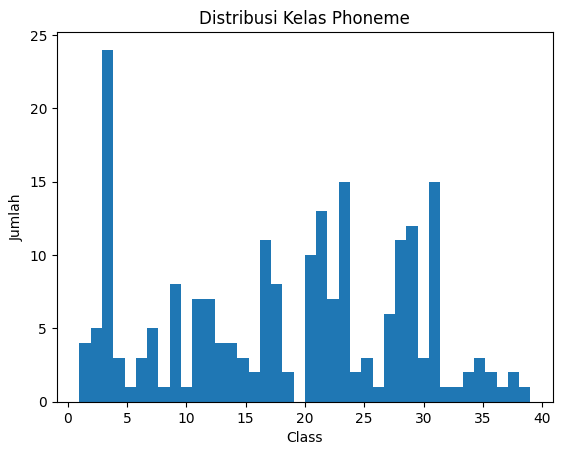

In [15]:
import matplotlib.pyplot as plt

plt.hist(y_train, bins=40)
plt.title("Distribusi Kelas Phoneme")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.show()


### **Visualisasi Contoh Time Series**

---
Kode tersebut digunakan untuk menampilkan contoh sinyal phoneme dari data latih dalam bentuk grafik time series. Baris `plt.plot(X_train[0])` memvisualisasikan satu sampel data, yaitu sinyal suara phoneme pertama, sehingga dapat terlihat pola perubahan amplitudo terhadap waktu. Visualisasi ini membantu memahami karakteristik data, seperti fluktuasi sinyal, kestabilan, dan bentuk pola suara yang direpresentasikan dalam dataset. Grafik ini termasuk bagian dari eksplorasi data (EDA) karena memberikan gambaran awal tentang struktur dan sifat sinyal phoneme sebelum dilakukan preprocessing dan pemodelan.




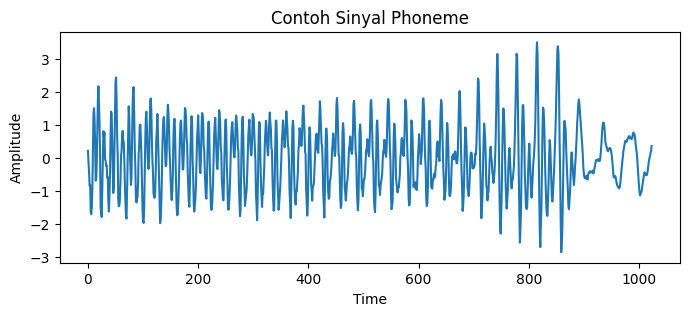

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))
plt.plot(X_train[0])
plt.title("Contoh Sinyal Phoneme")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


# **PREPROCESSING DATA**

### **Encode Label**

---

Kode tersebut digunakan untuk mengubah label kelas phoneme yang awalnya berbentuk nilai kategori atau angka tidak berurutan menjadi label numerik berurutan yang dapat diproses oleh algoritma machine learning. `LabelEncoder` memetakan setiap kelas unik pada data latih ke dalam bilangan bulat mulai dari 0, lalu menerapkan pemetaan yang sama pada data uji agar konsisten. Proses ini penting karena sebagian besar algoritma klasifikasi, termasuk SVM, membutuhkan label dalam bentuk numerik. Bagian akhir kode menampilkan contoh label sebelum dan sesudah proses encoding untuk memastikan bahwa transformasi label telah berjalan dengan benar.


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Label awal:", np.unique(y_train)[:5])
print("Label encoded:", np.unique(y_train_enc)[:5])


Label awal: [1 2 3 4 5]
Label encoded: [0 1 2 3 4]


### **Scaling**

---

Kode tersebut digunakan untuk melakukan standarisasi fitur pada data phoneme sebelum digunakan dalam proses pemodelan. `StandardScaler` mengubah setiap fitur agar memiliki nilai rata-rata 0 dan simpangan baku 1, sehingga skala antar fitur menjadi seragam. Proses `fit_transform` diterapkan pada data latih untuk mempelajari parameter skala, sedangkan `transform` diterapkan pada data uji menggunakan parameter yang sama agar tidak terjadi kebocoran data. Standarisasi ini sangat penting terutama untuk algoritma seperti SVM, karena perbedaan skala fitur dapat memengaruhi jarak dan batas keputusan yang dibentuk oleh model.


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# **PEMODELAN DATA (SVM)**

---

Output tersebut menunjukkan ringkasan model Support Vector Classifier (SVC) yang telah dibuat dengan parameter tertentu. Nilai `C=20` menandakan pengaturan toleransi kesalahan klasifikasi, `class_weight='balanced'` digunakan untuk menyesuaikan bobot kelas agar model tidak berat sebelah jika jumlah data tiap kelas tidak seimbang, dan `random_state=42` memastikan hasil pelatihan konsisten saat dijalankan ulang. Tampilan ini bukan hasil prediksi, melainkan informasi bahwa model SVM berhasil dikonfigurasi dan siap digunakan untuk melakukan klasifikasi pada data phoneme.


In [18]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=20,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train_enc)


SVC(C=20, class_weight='balanced', random_state=42)

# **EVALUASI**

---
Kode tersebut digunakan untuk mengevaluasi kinerja model SVM setelah proses pelatihan selesai. Model melakukan prediksi terhadap data uji yang telah distandarisasi, kemudian hasil prediksi tersebut dibandingkan dengan label sebenarnya. Nilai akurasi menunjukkan persentase prediksi yang benar secara keseluruhan. `classification_report` memberikan informasi yang lebih rinci untuk setiap kelas, seperti precision, recall, dan f1-score, sehingga performa model pada masing-masing phoneme dapat dianalisis. Parameter `zero_division=0` digunakan untuk mencegah munculnya peringatan ketika suatu kelas tidak memiliki prediksi, sehingga hasil evaluasi tetap dapat ditampilkan dengan jelas.



In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred, zero_division=0))


Accuracy: 0.11867088607594936

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        38
           1       0.00      0.00      0.00        49
           2       0.11      0.72      0.19       214
           3       0.00      0.00      0.00        23
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00        30
           6       0.00      0.00      0.00        42
           7       0.00      0.00      0.00        11
           8       0.00      0.00      0.00        70
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00        59
          11       0.00      0.00      0.00        61
          12       0.00      0.00      0.00        37
          13       0.00      0.00      0.00        34
          14       0.00      0.00      0.00        23
          15       0.00      0.00      0.00        15
          16       0.12   

### **Confusion Matrix**

---

Kode tersebut digunakan untuk menampilkan confusion matrix agar dapat melihat perbandingan antara label asli dan hasil prediksi model SVM. Grafik ini membantu mengetahui kelas phoneme mana yang berhasil diprediksi dengan benar dan kelas mana yang sering salah diprediksi. Setiap warna pada matriks menunjukkan jumlah data, semakin terang warnanya berarti semakin banyak data pada posisi tersebut.

Hasil confusion matrix terlihat seperti ini karena model SVM banyak memprediksi data ke beberapa kelas tertentu saja. Artinya, model belum mampu membedakan seluruh kelas phoneme dengan baik. Hal ini bisa disebabkan oleh data yang tidak seimbang antar kelas, pola sinyal yang mirip antar phoneme, atau pengaturan parameter SVM yang belum optimal, sehingga performa model masih perlu ditingkatkan.


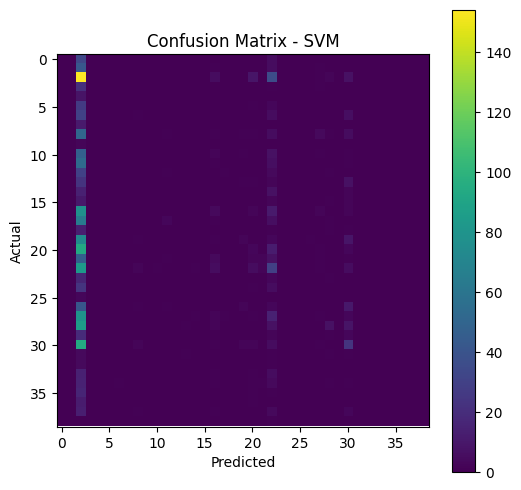

In [22]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


### **Link Deplyoment:**

https://23094phoneme.streamlit.app/